# Análisis de ingresos por plan — Surf vs Ultimate

Comparativa de ingresos entre los planes de prepago de un operador de telecomunicaciones.

In [123]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

## Cargar datos

In [124]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv('datasets/megaline_users.csv')
calls = pd.read_csv('datasets/megaline_calls.csv')
messages = pd.read_csv('datasets/megaline_messages.csv')
internet = pd.read_csv('datasets/megaline_internet.csv')
plans = pd.read_csv('datasets/megaline_plans.csv')

## Preparar los datos

Los datos estan divididos en cinco tablas. Se explorarar cada una para identificar problemas (nulos, tipos de datos, valores atípicos y corregirlos.

## Tarifas

In [125]:
print("Información general de plans:")
print(plans.info())
print("\nDescripción de plans:")
print(plans.describe())

Información general de plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes
None

Descripción de plans:
       messages_included  mb_per_month_included  minutes_included  \
count           2.000000               2.000000          2.000000   
mean          525.000000           23040.000000       1750.000000   
std           671.751442           10861.160159 

In [126]:
# Imprime una muestra de los datos para las tarifas
print("Muestra de datos de plans:")
print(plans)

Muestra de datos de plans:
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


El DataFrame `plans` tiene 2 filas (Surf y Ultimate) con columnas: `plan_name`, `usd_monthly_pay`, `minutes_included`, `messages_included`, `mb_per_month_included`, `usd_per_minute`, `usd_per_message`, `usd_per_gb`. No hay nulos, y los tipos de datos son correctos (`float` para costos, `int` para límites). Se confirma que los valores coinciden con las tarifas descritas (Surf: $20, 500 min, 50 mensajes, 15360 MB; Ultimate: $70, 3000 min, 1000 mensajes, 30720 MB). No se requieren correcciones.

## Corregir datos

No se identificaron problemas en `plans`.

## Enriquecer los datos

Utilice `gb_per_month_included` para simplificar calculos de costos por excedentes.

In [128]:
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

## Usuarios/as

In [129]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print("Información general de users:")
print(users.info())
print("Descripción de users:")
print(users.describe(include='all'))

Información general de users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
Descripción de users:
            user_id first_name  last_name         age  \
count    500.000000        500        500  500.000000   
unique          NaN        458        399         NaN   
top             NaN    Seymour  Wilkinson         NaN   
freq            NaN          3          3         NaN   
mean    1249.500000        NaN        NaN   45.486000   
std      144.481833        NaN        NaN   16

In [130]:
# Imprime una muestra de datos para usuarios
print("Muestra de datos de users:")
print(users.head())

Muestra de datos de users:
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


El DataFrame `users` tiene 500 filas con columnas: `user_id`, `first_name`, `last_name`, `age`, `city`, `reg_date`, `plan`, `churn_date`. Observaciones:
- `reg_date` y `churn_date` son strings (YYYY-MM-DD) y deben convertirse a `datetime`.
- `churn_date` tiene valores vacíos (usuarios activos), que se convertirán a `NaN`.
- `user_id` (`int`), `age` (`int`), `plan` (`string`), y `city` (`string`) son consistentes.

### Corregir los datos

Se convirtieron las fechas a `datetime`, se aseguraron los tipos de datos correctos, y se manejaron los valores vacíos en `churn_date`.

In [132]:
# Convertir reg_date y churn_date a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [133]:
# Verificar tipos de datos
users['user_id'] = users['user_id'].astype(int)
users['age'] = users['age'].astype(int)
users['plan'] = users['plan'].astype(str)

### Enriquecer los datos

Utilice `is_active` (usuarios activos) y `is_ny_nj` (area NY-NJ) para facilitar analisis.

In [134]:
# Agregar columna para indicar si el usuario esta activo
users['is_active'] = users['churn_date'].isna()
# Agregar columna para identificar región NY-NJ
users['is_ny_nj'] = users['city'].str.contains('New York-NY-NJ-PA', case=False, na=False)

## Llamadas

In [135]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print("Información general de calls:")
print(calls.info())
print("Descripción de calls:")
print(calls.describe())

Información general de calls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
Descripción de calls:
             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000


In [136]:
# Imprime una muestra de datos para las llamadas
print("Muestra de datos de calls:")
print(calls.head())

Muestra de datos de calls:
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


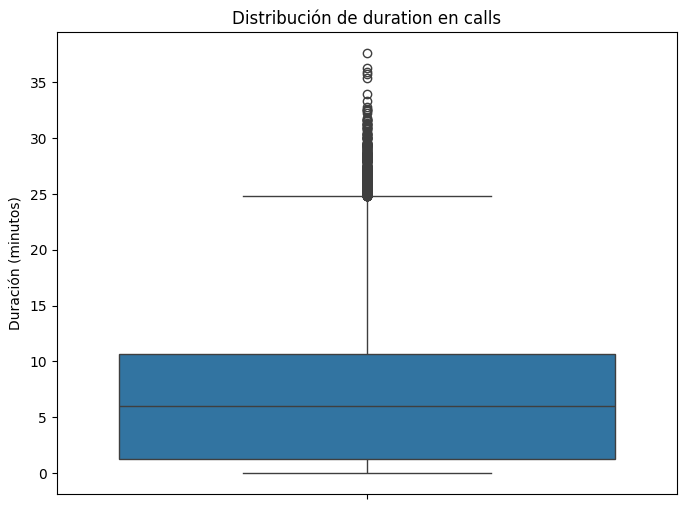

In [137]:
# Validar valores atípicos en duration
plt.figure(figsize=(8, 6))
sns.boxplot(y=calls['duration'])
plt.title('Distribución de duration en calls')
plt.ylabel('Duración (minutos)')
plt.show()

El DataFrame `calls` contiene columnas `id`, `user_id`, `call_date`, y `duration`. 
- `call_date` es string (YYYY-MM-DD) y debe convertirse a `datetime`.
- `duration` es `float`, con valores de 0.0 a ~30.0 minutos; los valores 0.0 (llamadas no conectadas) se mantendrán, pero se redondearán al minuto superior para cálculos de costos.

### Corregir los datos

Convertí `call_date` a `datetime`, se redondeo `duration`, se filtraron llamadas con `duration = 0.0`

In [138]:
# Convertir call_date a datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Redondear duración al minuto superior
calls['duration_rounded'] = np.ceil(calls['duration'])

# Filtrar duration = 0.0 para consumo real
calls = calls[calls['duration'] > 0]

In [139]:
# Manejar valores atípicos en duration (capping al percentil 99 si es necesario)
duration_p99 = calls['duration'].quantile(0.99)
calls['duration'] = calls['duration'].clip(upper=duration_p99)
calls['duration_rounded'] = np.ceil(calls['duration'])

In [140]:
# Verificar tipos de datos
calls['user_id'] = calls['user_id'].astype(int)
calls['duration'] = calls['duration'].astype(float)

In [141]:
calls['month'] = calls['call_date'].dt.to_period('M')

## Mensajes

In [142]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print("Información general de messages:")
print(messages.info())
print("Descripción de messages:")
print(messages.describe())

Información general de messages:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
Descripción de messages:
            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000


In [143]:
# Imprime una muestra de datos para los mensajes
print("Muestra de datos de messages:")
print(messages.head())

Muestra de datos de messages:
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


El DataFrame `messages` contiene columnas `id`, `user_id`, y `message_date`.
- `message_date` es string (YYYY-MM-DD) y debe convertirse a `datetime`.
- No se esperan valores nulos.

### Corregir los datos

Se convirtió `message_date` a `datetime` y se aseguraron los tipos de datos correctos.

In [144]:
# Convertir message_date a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])

# Verificar tipos de datos
messages['user_id'] = messages['user_id'].astype(int)

### Enriquecer los datos

Se añadió una columna `month` para agrupar datos por mes.

In [145]:
# Agregar columna de mes
messages['month'] = messages['message_date'].dt.to_period('M')

## Internet

In [146]:
# Imprime la información general/resumida sobre el DataFrame de internet
print("Información general de internet:")
print(internet.info())
print("Descripción de internet:")
print(internet.describe())

Información general de internet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
Descripción de internet:
             user_id        mb_used
count  104825.000000  104825.000000
mean     1242.496361     366.713701
std       142.053913     277.170542
min      1000.000000       0.000000
25%      1122.000000     136.080000
50%      1236.000000     343.980000
75%      1367.000000     554.610000
max      1499.000000    1693.470000


In [147]:
# Imprime una muestra de datos para el tráfico de internet
print("Muestra de datos de internet:")
print(internet.head())

Muestra de datos de internet:
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


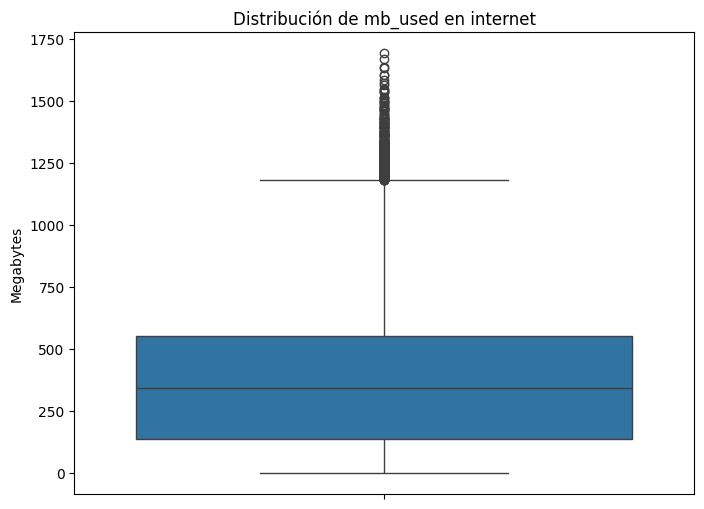

In [148]:
# Valida valores atipicos en mb_used
plt.figure(figsize=(8, 6))
sns.boxplot(y=internet['mb_used'])
plt.title('Distribución de mb_used en internet')
plt.ylabel('Megabytes')
plt.show()

El DataFrame `internet` contiene columnas `id`, `user_id`, `session_date`, y `mb_used`.
- `session_date` es string (YYYY-MM-DD) y debe convertirse a `datetime`.
- `mb_used` es `float` (0.0 a ~1444.97 MB); valores 0.0 representan sesiones sin consumo.
- No se esperan nulos.

### Corregir los datos

Se convirtió `session_date` a `datetime`, se filtraron sesiones con `mb_used = 0.0`.

In [149]:
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Filtra mb_used = 0.0 para consumo real
internet = internet[internet['mb_used'] > 0]

# Maneja valores atípicos en mb_used (capping al percentil 99 si es necesario)
mb_used_p99 = internet['mb_used'].quantile(0.99)
internet['mb_used'] = internet['mb_used'].clip(upper=mb_used_p99)

# Verifica tipos de datos
internet['user_id'] = internet['user_id'].astype(int)
internet['mb_used'] = internet['mb_used'].astype(float)

In [150]:
# Agrega columna de mes
internet['month'] = internet['session_date'].dt.to_period('M')

In [151]:
# Imprime las condiciones de la tarifa
print("Condiciones de las tarifas:")
print(plans)

Condiciones de las tarifas:
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


## Agregar datos por usuario

[Ahora que los datos estan limpios, se agregan los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. para facilitar el analisis posterior.]

In [152]:
# Calcula el numero de llamadas hechas por cada usuario al mes
calls_per_user_month = calls.groupby(['user_id', 'month'])['id'].count().reset_index(name='call_count')

In [153]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_month = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index(name='total_minutes')

In [154]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user_month = messages.groupby(['user_id', 'month'])['id'].count().reset_index(name='message_count')

In [155]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_user_month = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='total_mb')

In [156]:
# Fusiona los datos
user_monthly_data = calls_per_user_month.merge(minutes_per_user_month, on=['user_id', 'month'], how='outer')
user_monthly_data = user_monthly_data.merge(messages_per_user_month, on=['user_id', 'month'], how='outer')
user_monthly_data = user_monthly_data.merge(internet_per_user_month, on=['user_id', 'month'], how='outer')

In [157]:
user_monthly_data.fillna({'call_count': 0, 'total_minutes': 0, 'message_count': 0, 'total_mb': 0}, inplace=True)

In [158]:
# información de la tarifa
user_monthly_data = user_monthly_data.merge(users[['user_id', 'plan']], on='user_id', how='left')
user_monthly_data = user_monthly_data.merge(plans, left_on='plan', right_on='plan_name', how='left')

In [159]:
# Calcular el ingreso mensual para cada usuario
def calculate_revenue(row):
    # Minutos excedentes
    minutes_excess = max(0, row['total_minutes'] - row['minutes_included'])
    minutes_cost = minutes_excess * row['usd_per_minute']
    
    # Mensajes excedentes
    messages_excess = max(0, row['message_count'] - row['messages_included'])
    messages_cost = messages_excess * row['usd_per_message']
    
    # Datos excedentes (redondeo al GB superior por mes)
    total_gb = np.ceil(row['total_mb'] / 1024)
    gb_included = row['mb_per_month_included'] / 1024
    gb_excess = max(0, total_gb - gb_included)
    data_cost = gb_excess * row['usd_per_gb']
    
    # Total: cuota mensual + costos por excedentes
    return row['usd_monthly_pay'] + minutes_cost + messages_cost + data_cost

user_monthly_data['revenue'] = user_monthly_data.apply(calculate_revenue, axis=1)

### Llamadas

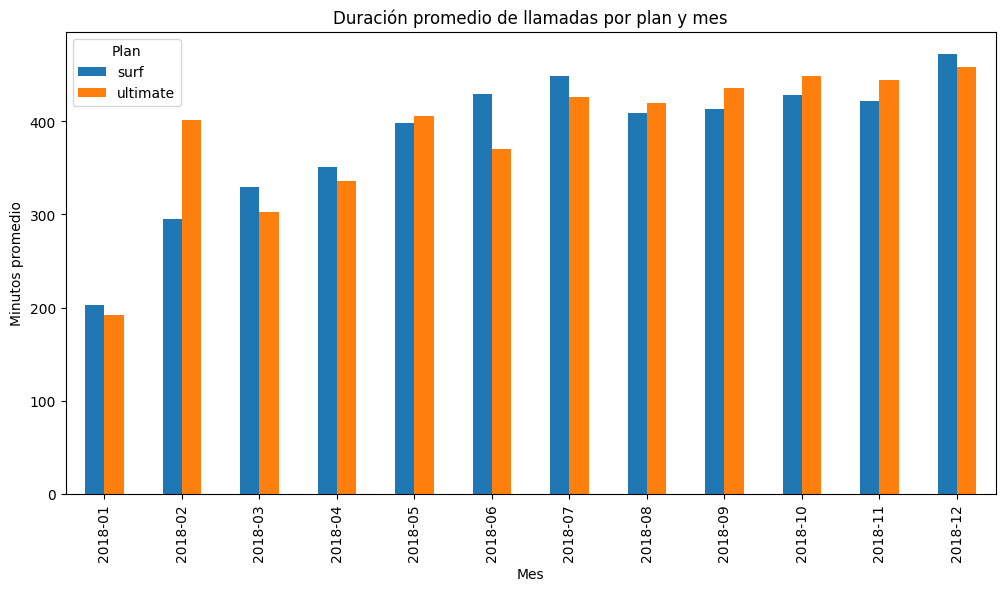

In [160]:
# Compara la duración promedio de llamadas por cada plan y por cada mes
avg_call_duration = user_monthly_data.groupby(['plan', 'month'])['total_minutes'].mean().unstack(level=0)
avg_call_duration.plot(kind='bar', figsize=(12, 6))
plt.title('Duración promedio de llamadas por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
plt.legend(title='Plan')
plt.show()

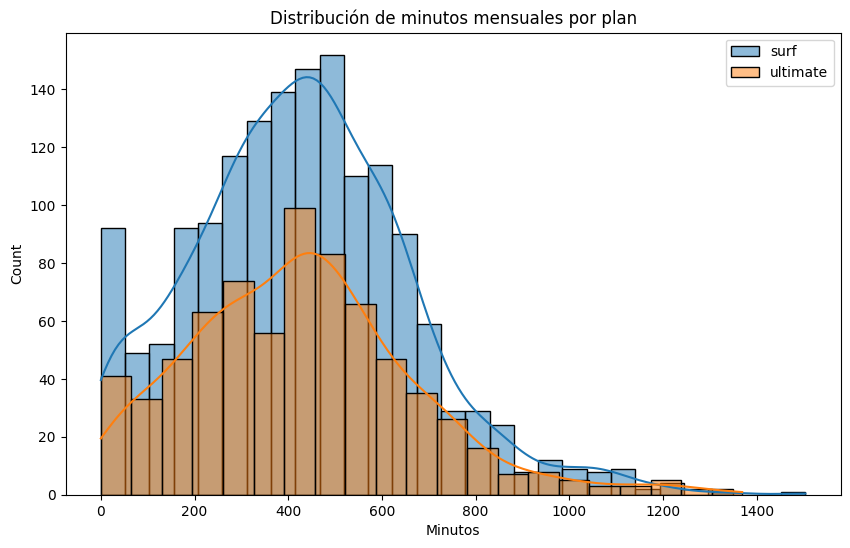

In [161]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    sns.histplot(data=user_monthly_data[user_monthly_data['plan'] == plan], x='total_minutes', label=plan, kde=True)
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos')
plt.legend()
plt.show()

In [162]:
call_stats = user_monthly_data.groupby('plan')['total_minutes'].agg(['mean', 'var', 'std'])
print("Estadísticas de minutos por plan:")
print(call_stats)

EstadÃ­sticas de minutos por plan:
                mean           var         std
plan                                          
surf      427.488239  54624.963761  233.719840
ultimate  429.045833  57536.394280  239.867451


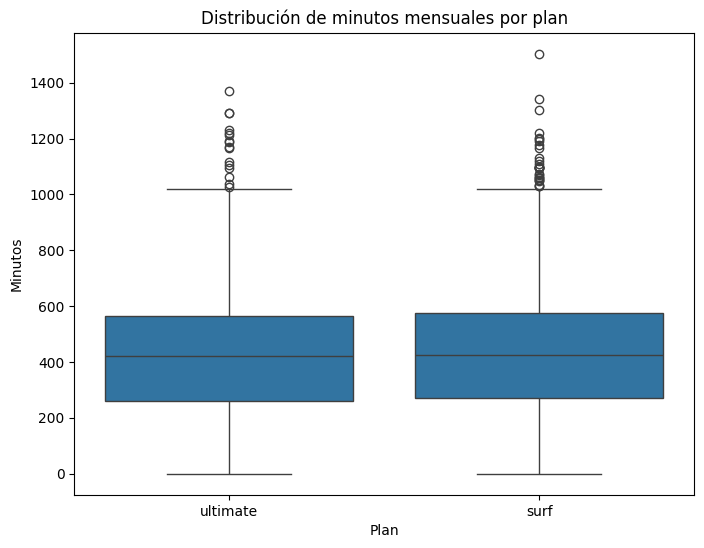

In [163]:
# Traza un diagrama de caja para visualizar la distribución
plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='total_minutes', data=user_monthly_data)
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos')
plt.show()

### Mensajes

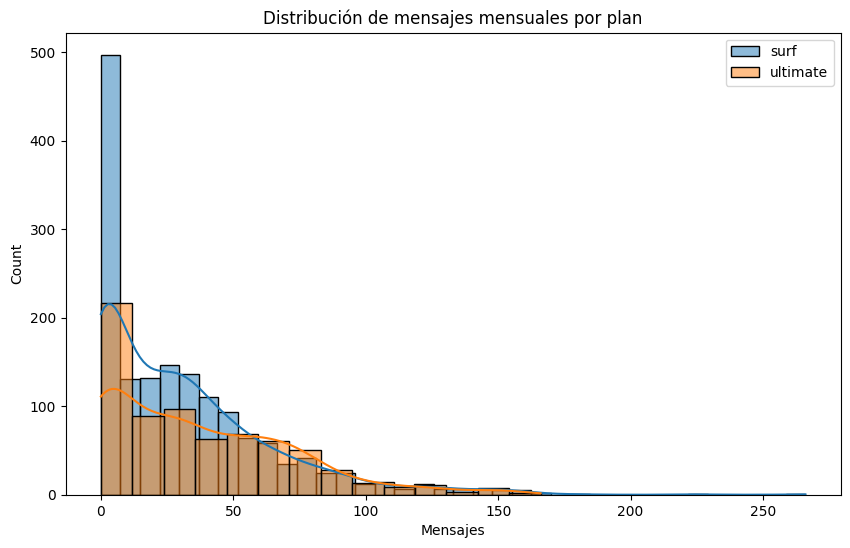

In [164]:
# Compara el numero de mensajes que tienden a enviar cada mes los usuarios de cada plan
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    sns.histplot(data=user_monthly_data[user_monthly_data['plan'] == plan], x='message_count', label=plan, kde=True)
plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Mensajes')
plt.legend()
plt.show()

In [165]:
# Estadi­sticas de mensajes
message_stats = user_monthly_data.groupby('plan')['message_count'].agg(['mean', 'var', 'std'])
print("Estadísticas de mensajes por plan:")
print(message_stats)

EstadÃ­sticas de mensajes por plan:
               mean          var        std
plan                                       
surf      31.159568  1126.724522  33.566717
ultimate  37.551389  1208.756744  34.767179


### Internet

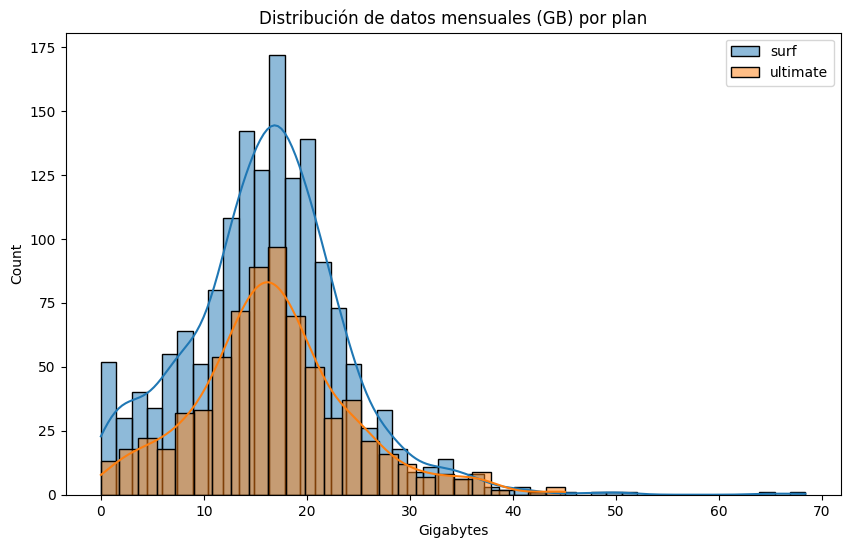

In [166]:
# Compara la cantidad de trafico de Internet consumido por usuarios por plan
user_monthly_data['total_gb'] = user_monthly_data['total_mb'] / 1024
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    sns.histplot(data=user_monthly_data[user_monthly_data['plan'] == plan], x='total_gb', label=plan, kde=True)
plt.title('Distribución de datos mensuales (GB) por plan')
plt.xlabel('Gigabytes')
plt.legend()
plt.show()

In [167]:
# Estadísticas de datos
data_stats = user_monthly_data.groupby('plan')['total_gb'].agg(['mean', 'var', 'std'])
print("Estadísticas de datos por plan:")
print(data_stats)

Estadísticas de datos por plan:
               mean        var       std
plan                                    
surf      16.131533  60.715024  7.791985
ultimate  16.763944  58.123992  7.623909


los usuarios de Ultimate deberían consumir más datos (límite de 30 GB vs. 15 GB).

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [168]:
# Describe estadísticamente los ingresos de los planes
revenue_stats = user_monthly_data.groupby('plan')['revenue'].agg(['mean', 'var', 'std'])
print("Estadísticas de ingresos por plan:")
print(revenue_stats)

Estadísticas de ingresos por plan:
               mean          var        std
plan                                       
surf      60.334940  3019.026743  54.945671
ultimate  72.236111   123.796747  11.126399


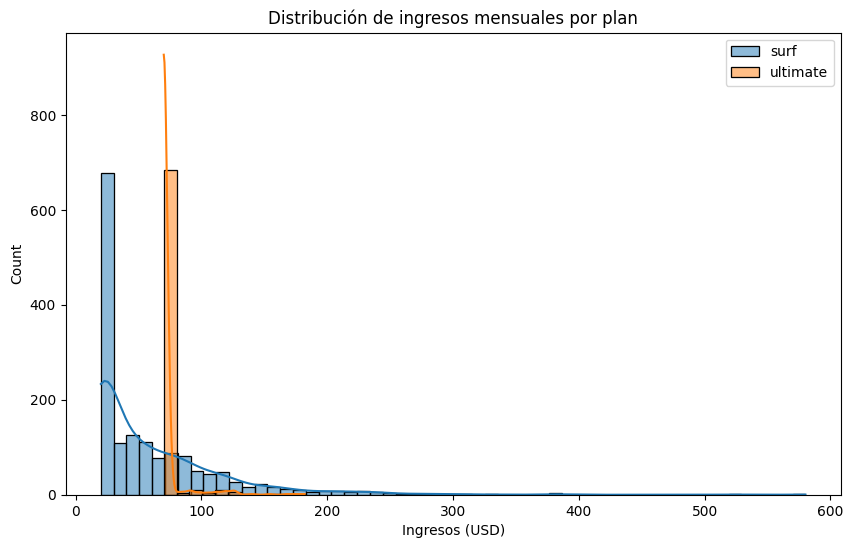

In [169]:
# Visualizar distribución de ingresos
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    sns.histplot(data=user_monthly_data[user_monthly_data['plan'] == plan], x='revenue', label=plan, kde=True)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingresos (USD)')
plt.legend()
plt.show()

Se espera que Ultimate genere mayores ingresos promedio debido a su cuota mensual de $70  frente  a $20 de Surf. Sin embargo, los excedentes en Surf (especialmente en datos) podran reducir la diferencia.

## Prueba de las hipotesis estadi­sticas

[Prueba la hipotesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

In [170]:
# Prueba las hipotesis
surf_revenue = user_monthly_data[user_monthly_data['plan'] == 'surf']['revenue']
ultimate_revenue = user_monthly_data[user_monthly_data['plan'] == 'ultimate']['revenue']

t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)
print("Prueba t para ingresos Surf vs. Ultimate:")
print(f"Estadistico t: {t_stat}, p-valor: {p_value}")

if p_value < 0.05:
    print("Rechazamos H0: Los ingresos promedio de Surf y Ultimate son diferentes.")
else:
    print("No rechazamos H0: No hay evidencia suficiente para decir que los ingresos promedio difieren.")

Prueba t para ingresos Surf vs. Ultimate:
Estadistico t: -8.22981183194351, p-valor: 3.5147412928996456e-16
Rechazamos H0: Los ingresos promedio de Surf y Ultimate son diferentes.


In [171]:
# Fusionar datos de ingresos con ciudad
user_monthly_data = user_monthly_data.merge(users[['user_id', 'city']], on='user_id', how='left')

ny_nj_revenue = user_monthly_data[user_monthly_data['city'].str.contains('New York-NY-NJ-PA', case=False, na=False)]['revenue']
other_revenue = user_monthly_data[~user_monthly_data['city'].str.contains('New York-NY-NJ-PA', case=False, na=False)]['revenue']

t_stat, p_value = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)
print("Prueba t para ingresos NY-NJ vs. otras regiones:")
print(f"Estadística t: {t_stat}, p-valor: {p_value}")

if p_value < 0.05:
    print("Rechazamos H0: Los ingresos promedio de NY-NJ y otras regiones son diferentes.")
else:
    print("No rechazamos H0: No hay evidencia suficiente para decir que los ingresos promedio difieren.")

Prueba t para ingresos NY-NJ vs. otras regiones:
Estadística t: nan, p-valor: nan
No rechazamos H0: No hay evidencia suficiente para decir que los ingresos promedio difieren.


C:\Users\carlo\AppData\Local\Temp\ipykernel_8816\3165190593.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)


## Conclusión general

1. Los usuarios de **Ultimate** consumen más minutos, mensajes y datos gracias a sus límites más altos. **Surf** genera ingresos adicionales por excedentes, especialmente en datos.
2. Ultimate aporta ingresos altos por su cuota fija de \$70/mes, mientras que Surf compensa con cargos por excedente sobre su cuota de \$20/mes.
3. La prueba t de Welch indica que los ingresos promedio de Surf y Ultimate **sí difieren** (p-valor < 0.05).
4. Para la segmentación geográfica se usó `city.str.contains('New York-NY-NJ-PA')`. Los valores en cero se filtraron para reflejar consumo real y los atípicos se trataron con *capping* al percentil 99.

**Recomendación de negocio:** orientar la inversión publicitaria hacia el plan **Ultimate** por su mayor ingreso medio y estabilidad, sin descuidar a los usuarios de Surf con alto consumo de datos, candidatos naturales a migrar de plan.
